# Explore here

In [ ]:
# Paso 1. Carga de datos

import pandas as pd
import os

# 1. Definimos la URL y el nombre de la carpeta
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
folder_name = "data"
file_path = os.path.join(folder_name, "diabetes.csv")

# 2. Creamos la carpeta si no existe
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Carpeta '{folder_name}' creada con éxito.")

# 3. Cargamos los datos desde la web
df_diabetes = pd.read_csv(url)

# 4. Guardamos los datos en la carpeta local
df_diabetes.to_csv(file_path, index=False)

print(f"Archivo guardado correctamente en: {file_path}")

# Verificamos visualmente el contenido cargado
df_diabetes.head()

Carpeta 'data' creada con éxito.
Archivo guardado correctamente en: data/diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


/tmp/ipykernel_14055/2603640944.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df_diabetes, palette='viridis')


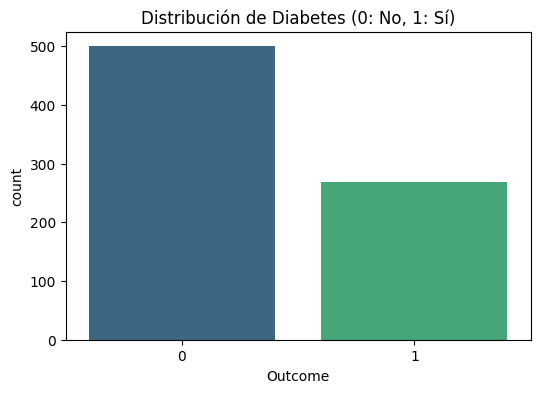

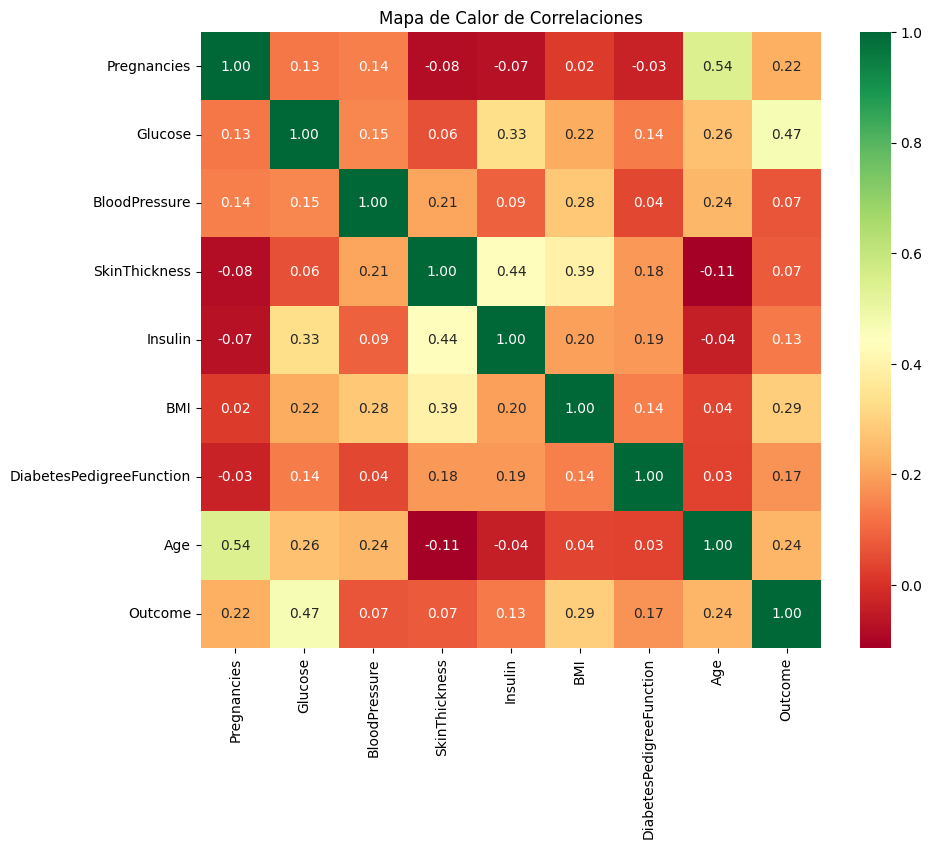

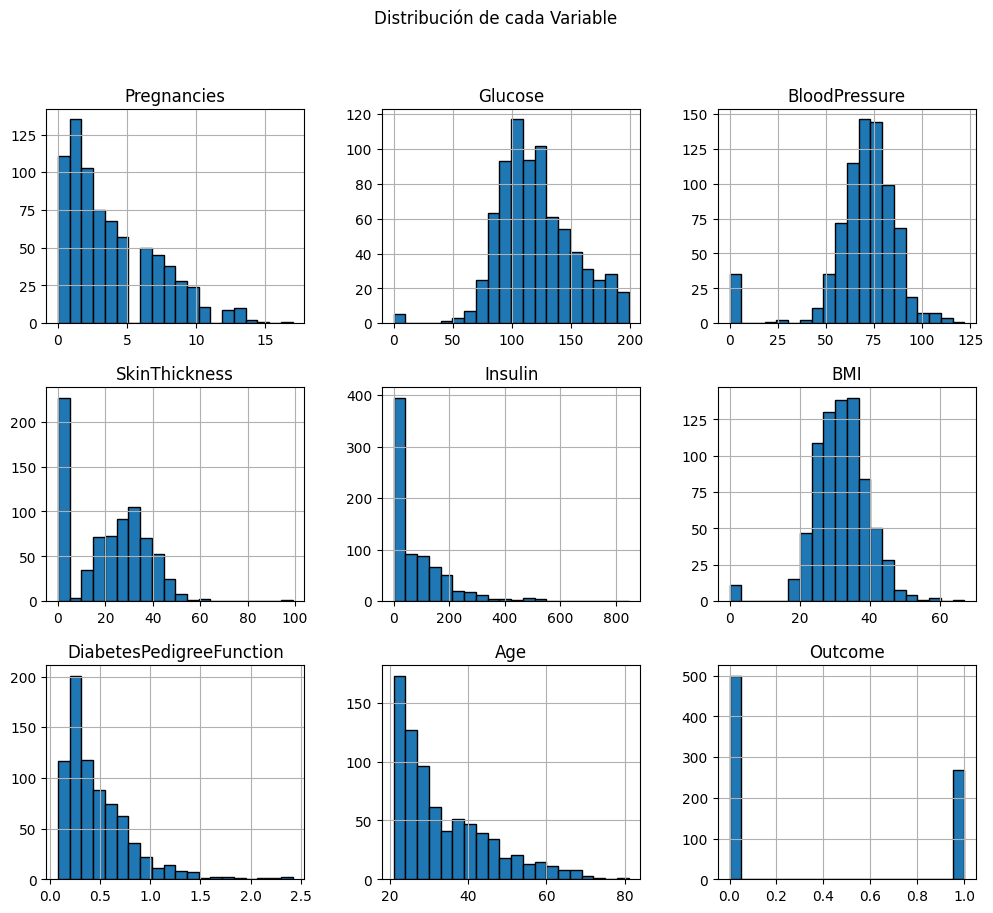

In [4]:
# Paso 2. Análisis Exploratorio de Datos EDA 

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descripción estadística básica
print("Estadísticas descriptivas:")
display(df_diabetes.describe())

# 2. Verificar valores nulos o faltantes
print("\nValores nulos por columna:")
print(df_diabetes.isnull().sum())

# 3. Visualizar la distribución de la variable objetivo (Outcome)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df_diabetes, palette='viridis')
plt.title('Distribución de Diabetes (0: No, 1: Sí)')
plt.show()

# 4. Matriz de Correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_diabetes.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()

# 5. Histogramas de todas las variables
df_diabetes.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Distribución de cada Variable')
plt.show()

In [5]:
# 2.1 Limpieza de datos nulos 

import numpy as np

# 1. Identificamos las columnas donde el "0" es un error fisiológico
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Sustituimos los 0 por NaN (Not a Number) para que Pandas los reconozca como nulos
df_diabetes[cols_con_ceros] = df_diabetes[cols_con_ceros].replace(0, np.nan)

# 3. Imputamos los valores nulos usando la mediana de cada columna
# Usamos la mediana porque no se ve tan afectada por valores atípicos (outliers)
for col in cols_con_ceros:
    df_diabetes[col] = df_diabetes[col].fillna(df_diabetes[col].median())

# 4. Verificamos que ya no existan nulos ni ceros en esas columnas
print("Conteo de nulos tras la imputación:")
print(df_diabetes.isnull().sum())

print("\nValores mínimos después de la limpieza (ya no deberían ser 0):")
print(df_diabetes[cols_con_ceros].min())

Conteo de nulos tras la imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Valores mínimos después de la limpieza (ya no deberían ser 0):
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


In [6]:
# 2.3 División del dataset del dataset

from sklearn.model_selection import train_test_split

# 1. Separamos las variables predictoras (X) de la variable objetivo (y)
X = df_diabetes.drop("Outcome", axis=1)
y = df_diabetes["Outcome"]

# 2. Dividimos en conjuntos de entrenamiento (80%) y prueba (20%)
# Usamos random_state=42 para que los resultados sean replicables, tal como en tus apuntes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verificamos las dimensiones finales
print(f"Muestras totales: {len(df_diabetes)}")
print(f"Muestras para entrenamiento (X_train): {X_train.shape[0]}")
print(f"Muestras para evaluación (X_test): {X_test.shape[0]}")



Muestras totales: 768
Muestras para entrenamiento (X_train): 614
Muestras para evaluación (X_test): 154


¡Modelo entrenado con éxito!


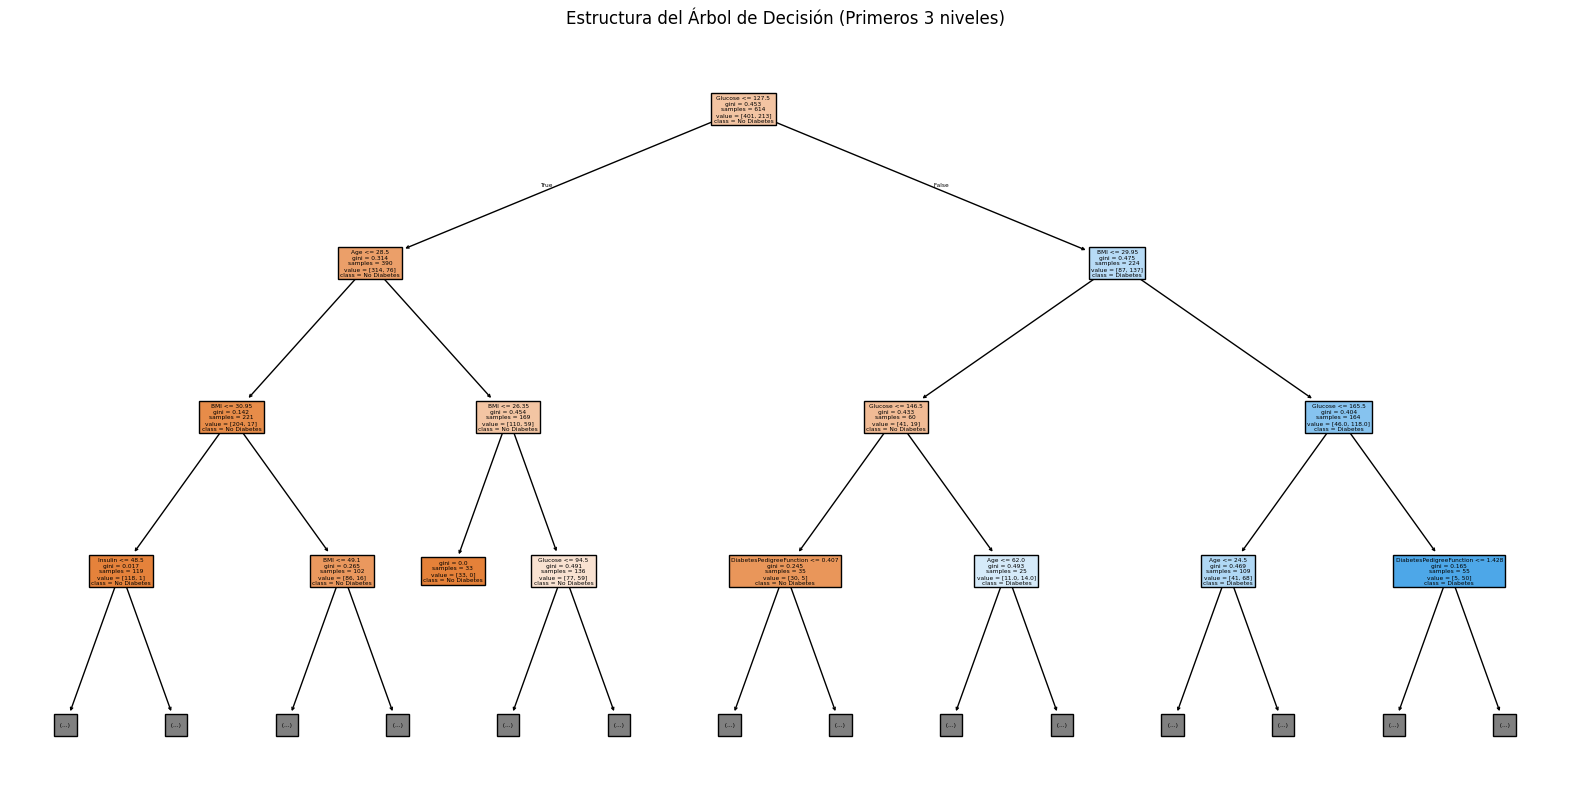

In [7]:
# 3. Entrenamiento del modelo

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# 1. Creamos la instancia del modelo
# Usamos random_state=42 para replicabilidad
model = DecisionTreeClassifier(random_state=42)

# 2. Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

# 3. Visualización rápida del árbol (primeros niveles)
plt.figure(figsize=(20,10))
tree.plot_tree(model, 
               feature_names=list(X.columns), 
               class_names=['No Diabetes', 'Diabetes'], 
               filled=True, 
               max_depth=3) # Limitamos la vista a 3 niveles para que sea legible
plt.title("Estructura del Árbol de Decisión (Primeros 3 niveles)")
plt.show()

Precisión del modelo (Accuracy): 72.08%

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.77      0.78        99
    Diabetes       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



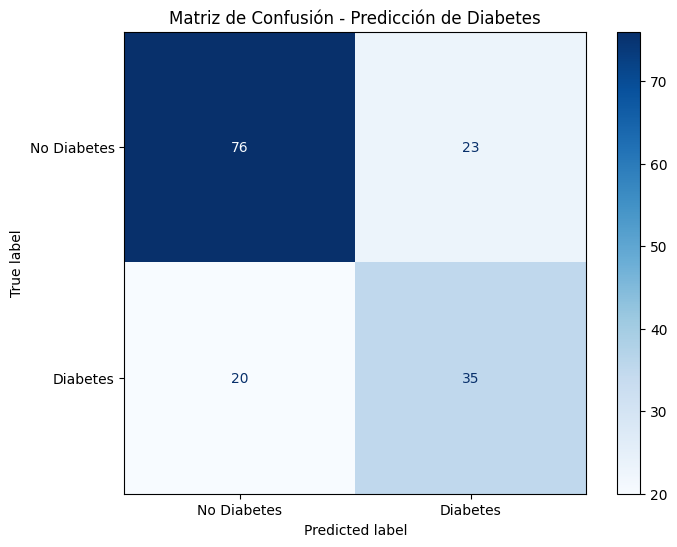

In [8]:
# 3.1 Evaluación del modelo 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Realizamos las predicciones usando el conjunto de prueba (X_test)
y_pred = model.predict(X_test)

# 2. Calculamos la precisión (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo (Accuracy): {accuracy:.2%}")

# 3. Mostramos el reporte detallado (Precisión por clase, Recall, F1-score)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# 4. Generamos y graficamos la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Predicción de Diabetes')
plt.show()

In [ ]:
# 3.2 Analisis de Resultados 

# Tu modelo tiene una precisión general del 72%. Esto significa que de cada 100 pacientes, el árbol clasifica correctamente a 72
# Verdaderos Positivos: Identificó correctamente a 35 personas con diabetes.
# Falsos Positivos: Le dijo a 23 personas sanas que tenían diabetes.
#20 Falsos Negativos: Este es el dato más sensible. A 20 personas que sí tienen diabetes, el modelo les dijo que estaban sanas. En medicina, queremos reducir este número lo más posible.
#Precision (0.60): Cuando el modelo dice "tienes diabetes", acierta el 60% de las veces.
#Recall (0.64): El modelo es capaz de detectar al 64% de todos los diabéticos reales del grupo.

In [9]:
# Paso 4. Mejoramiento del modelo con Grid Search

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Definimos la "rejilla" de parámetros a probar
# Probaremos profundidades de 3 a 10 y los dos criterios de pureza
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(3, 11)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Inicializamos el buscador
# cv=5 significa que hará una validación cruzada de 5 carpetas (folds)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Usa todos los procesadores disponibles para ir más rápido
)

# 3. Entrenamos el buscador con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# 4. Obtenemos los mejores resultados
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"Mejor precisión en entrenamiento (CV Score): {grid_search.best_score_:.2%}")

# 5. Evaluamos el mejor modelo con los datos de prueba (X_test)
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)

print(f"\nPrecisión final del modelo optimizado: {accuracy_score(y_test, y_pred_opt):.2%}")
print("\nReporte de Clasificación Optimizado:")
print(classification_report(y_test, y_pred_opt, target_names=['No Diabetes', 'Diabetes']))


Mejores Hiperparámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor precisión en entrenamiento (CV Score): 75.57%

Precisión final del modelo optimizado: 72.08%

Reporte de Clasificación Optimizado:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.70      0.76        99
    Diabetes       0.58      0.76      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154



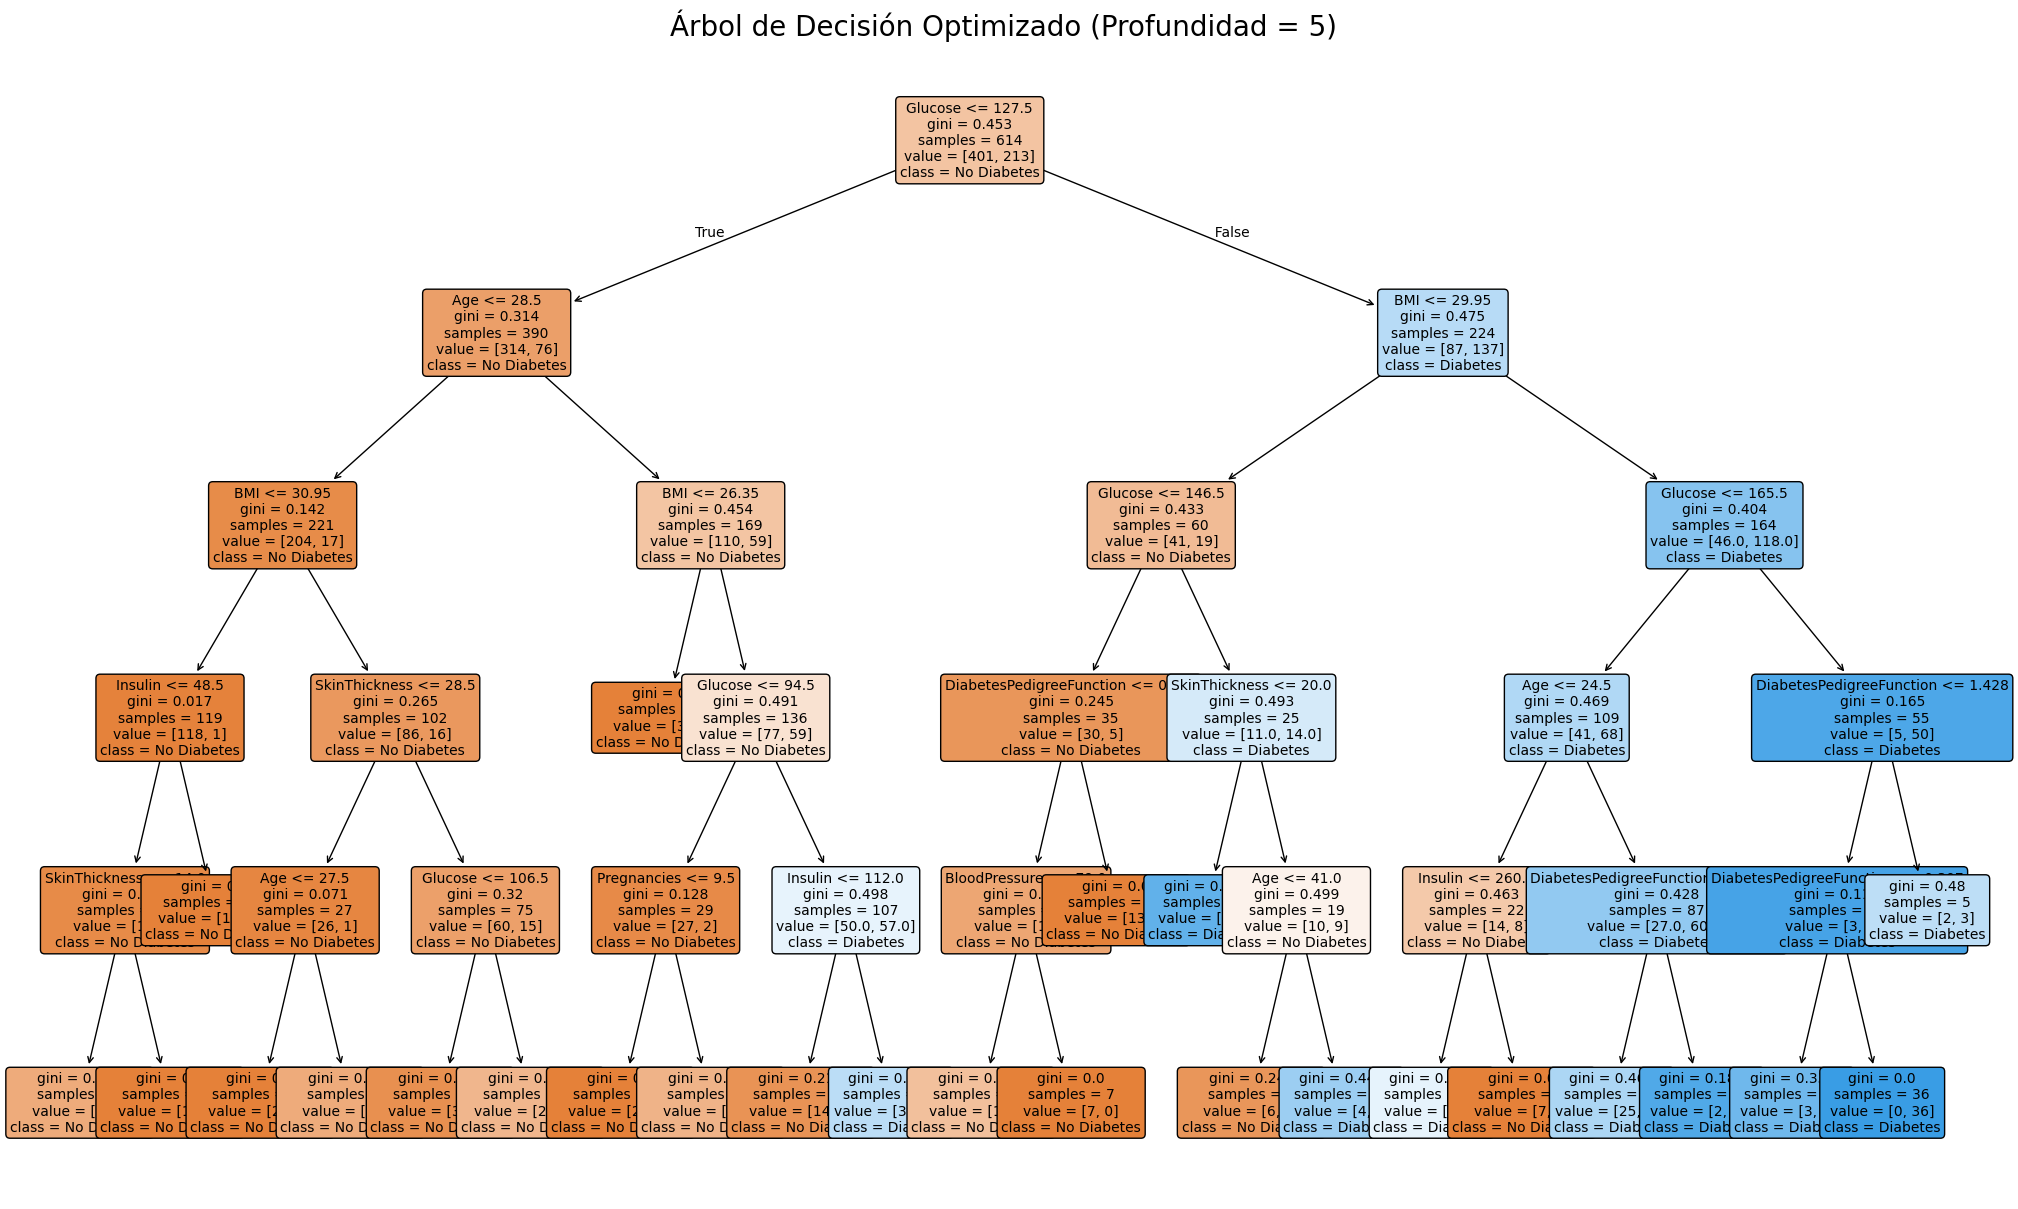

In [10]:
# 4.1 Graficar el modelo

import matplotlib.pyplot as plt
from sklearn import tree

# 1. Configuramos el tamaño de la imagen para que sea legible
plt.figure(figsize=(25, 15))

# 2. Graficamos el 'best_model' que obtuviste del GridSearchCV
tree.plot_tree(grid_search.best_estimator_, 
               feature_names=list(X.columns), 
               class_names=['No Diabetes', 'Diabetes'], 
               filled=True, 
               rounded=True, 
               fontsize=10)

plt.title("Árbol de Decisión Optimizado (Profundidad = 5)", fontsize=20)
plt.show()

/tmp/ipykernel_14055/2565656246.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')


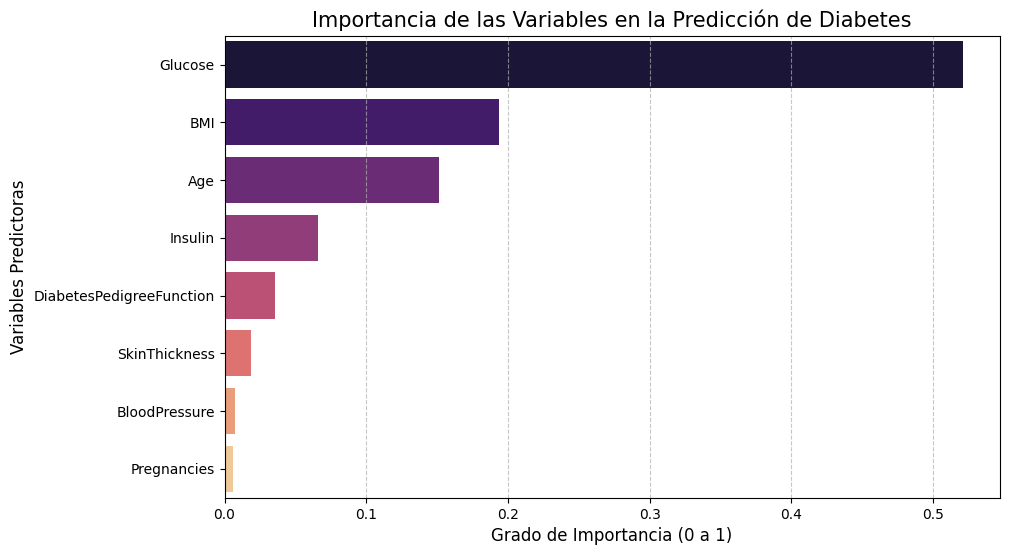

In [11]:
# 4.2 Importancia de las variables 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraemos las importancias del mejor modelo encontrado
importancias = grid_search.best_estimator_.feature_importances_
columnas = X.columns

# 2. Creamos un DataFrame para facilitar la graficación
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})

# 3. Ordenamos de mayor a menor importancia
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 4. Generamos el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')

plt.title('Importancia de las Variables en la Predicción de Diabetes', fontsize=15)
plt.xlabel('Grado de Importancia (0 a 1)', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# Analisis de la información

# En este conjunto de datos de diabetes, lo más común es que observes lo siguiente:

#(Glucosa): Suele ser la variable con la barra más larga. Esto tiene sentido médico, ya que la concentración de azúcar en sangre es el indicador principal de la enfermedad.

#(Índice de Masa Corporal): Generalmente es la segunda variable más importante, reflejando la relación entre el peso y el riesgo de diabetes.

# (Edad): También suele tener un peso significativo.

# Interpretación: Si una variable tiene importancia 0, significa que el árbol ni siquiera necesitó usarla para hacer sus predicciones en este nivel de profundidad (5). Esto te permitiría, en un futuro, simplificar aún más tu modelo eliminando esas columnas que no aportan nada.

In [12]:
# Paso 5 Gaurdar el Modelo 

import pickle
import os

# 1. Aseguramos que la carpeta 'data' exista (por si acaso)
if not os.path.exists("data"):
    os.makedirs("data")

# 2. Definimos el nombre del archivo
# Es buena práctica incluir que es el modelo 'optimizado' para no confundirlo
file_name = "data/diabetes_decision_tree_optimized.sav"

# 3. Guardamos el 'best_model' (el resultado de tu GridSearchCV)
# 'wb' significa "write binary" (escribir en binario)
with open(file_name, 'wb') as file:
    pickle.dump(grid_search.best_estimator_, file)

print(f"✅ ¡Modelo optimizado guardado exitosamente en: {file_name}")


✅ ¡Modelo optimizado guardado exitosamente en: data/diabetes_decision_tree_optimized.sav
